<a href="https://colab.research.google.com/github/Lekhanapriya-295/Machine_learning_models/blob/main/SMS_Spam_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import nltk

In [ ]:
df=pd.read_csv("spam.csv",encoding='latin-1')
df=df[['v1','v2']]
print(df.head())

     v1                                                 v2
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [ ]:
df.columns=['labels','message']
df.head()

,labels,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df.shape

(5572, 2)

In [ ]:
df['labels'].map({'ham':0,'spam':1})

,labels
0,0
1,0
2,1
3,0
4,0
...,...
5567,1
5568,0
5569,0
5570,0


**Text preprocessing**

In [ ]:
import nltk
import string
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words=stopwords.words('english')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
def cleantext(text):
  text=text.lower()
  text=text.translate(str.maketrans('','',string.punctuation))
  words=text.split()
  words=[word for word in words if word not in stop_words]
  return ' '.join(words)
df['message']=df['message'].apply(cleantext)

**Feature Extraction**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()
x = vectorizer.fit_transform(df['message'])
y = df['labels']

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

**Naive** **bayes**

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
nb = MultinomialNB()
nb.fit(x_train,y_train)
pred_nb = nb.predict(x_test)
accuracy_nb = accuracy_score(y_test,pred_nb)
print("Naive Bayes Accuracy:",accuracy_nb)

Naive Bayes Accuracy: 0.9659192825112107


 **Logistic regression**

In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train,y_train)
pred_lr = lr.predict(x_test)
print("Logistic Regression Accuracy:",accuracy_score(y_test,pred_lr))

Logistic Regression Accuracy: 0.9426008968609866


**Support vector** **machine**

In [ ]:
from sklearn.svm import SVC
svm = SVC()
svm.fit(x_train,y_train)
pred_svm = svm.predict(x_test)
print("Support vector machine Accuracy:",accuracy_score(y_test,pred_svm))

Support vector machine Accuracy: 0.967713004484305


**Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(x_train,y_train)
pred_rf = rf.predict(x_test)
accuracy_rf = accuracy_score(y_test,pred_rf)
print("Random Forest Accuracy:",accuracy_rf)

Random Forest Accuracy: 0.9739910313901345


**K-Nearest Neighbors**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(x_train,y_train)
pred_knn = knn.predict(x_test)
accuracy_kn = accuracy_score(y_test,pred_knn)
print("Knn Accuracy:",accuracy_kn)

Knn Accuracy: 0.905829596412556


**Confusion matrix**

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
cm=confusion_matrix(y_test,pred_nb)
print(cm)
print("Classification Report:\n", classification_report(y_test, pred_nb))

[[965   0]
 [ 38 112]]
Classification Report:
               precision    recall  f1-score   support

         ham       0.96      1.00      0.98       965
        spam       1.00      0.75      0.85       150

    accuracy                           0.97      1115
   macro avg       0.98      0.87      0.92      1115
weighted avg       0.97      0.97      0.96      1115



**Confusion matrix heatmap**

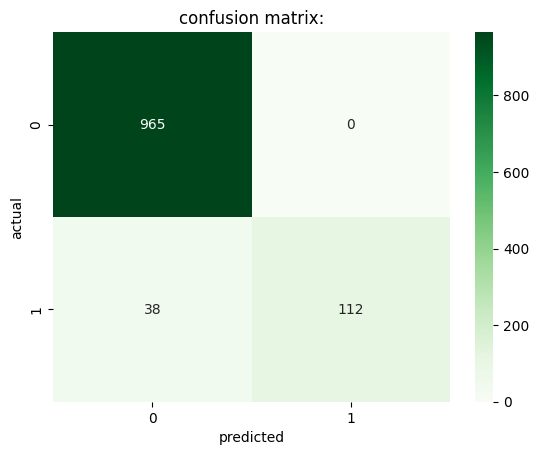

In [ ]:
sns.heatmap(cm,annot=True,fmt='d',cmap='Greens')
plt.title("confusion matrix:")
plt.xlabel("predicted")
plt.ylabel("actual")
plt.show()

**Bar graph**

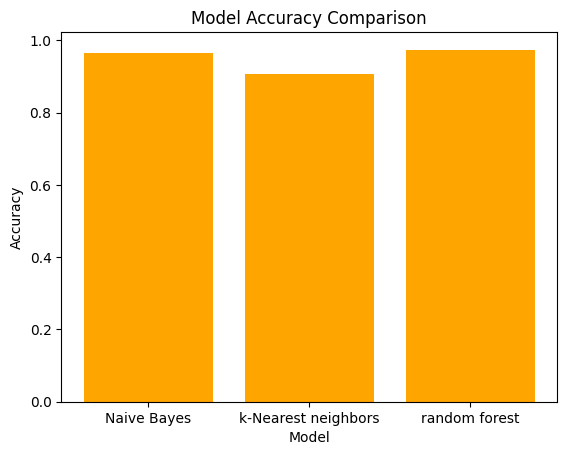

In [ ]:
model_names=["Naive Bayes","k-Nearest neighbors","random forest"]
accuracies=[accuracy_nb,accuracy_kn,accuracy_rf]
plt.bar(model_names,accuracies,color='orange')
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.show()

**Roc curve**

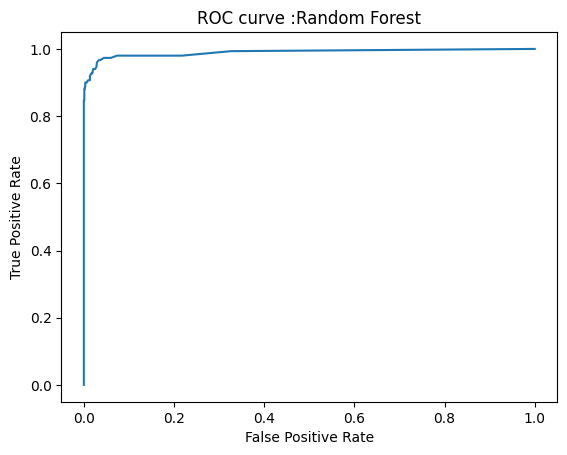

In [ ]:
from sklearn.metrics import roc_curve,auc
from sklearn.ensemble import RandomForestClassifier

rf_classifier = RandomForestClassifier()
rf_classifier.fit(x_train, y_train)

y_test_numerical = y_test.map({'ham': 0, 'spam': 1})

y_prob = rf_classifier.predict_proba(x_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test_numerical, y_prob)
plt.plot(fpr, tpr)
plt.title("ROC curve :Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [ ]:
def predict_spam(text):
    text = cleantext(text)
    text = vectorizer.transform([text])
    result = nb.predict(text)
    if result[0]=='spam':
        print("Spam Message")
    else:
        print("Ham Message")
predict_spam("Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's")
predict_spam("lets meet tomorrow")

Spam Message
Ham Message
